In [1]:
# 🔍 Model Interpretation
## Understanding How Features Affect Predictions
### COMPAS Recidivism Dataset

### What we will cover:
1. **Permutation Importance** — which features matter most?
2. **PDP (Partial Dependence Plots)** — how does each feature change predictions?
3. **Simple Group Effects** — how do predictions differ across groups?

Object `most` not found.
Object `predictions` not found.
Object `groups` not found.


In [2]:
# Cell 1 - Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Cell 2 - Load and prepare data with one-hot encoding
df = pd.read_csv(r'C:\Users\fo2225\criminal_justice_app\compas.csv')
df = df[['age', 'sex', 'race', 'priors_count', 'c_charge_degree', 'two_year_recid']].dropna()

# One-hot encode categorical variables
df = pd.get_dummies(df, columns=['sex', 'race', 'c_charge_degree'])

print("Columns after one-hot encoding:")
print(df.columns.tolist())

# Split features and target
X = df.drop('two_year_recid', axis=1)
y = df['two_year_recid']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"\nModel Accuracy: {acc:.1%}")
print(f"Features: {X.columns.tolist()}")


Columns after one-hot encoding:
['age', 'priors_count', 'two_year_recid', 'sex_Female', 'sex_Male', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'c_charge_degree_F', 'c_charge_degree_M']

Model Accuracy: 64.2%
Features: ['age', 'priors_count', 'sex_Female', 'sex_Male', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'c_charge_degree_F', 'c_charge_degree_M']


              Feature  Importance      Std
         priors_count    0.105059 0.011663
                  age    0.062024 0.011493
           race_Asian    0.000901 0.000318
 race_Native American    0.000832 0.000277
        race_Hispanic    0.000069 0.001765
    c_charge_degree_M   -0.006376 0.006342
    c_charge_degree_F   -0.006791 0.007552
           race_Other   -0.006861 0.001922
           sex_Female   -0.007277 0.004286
             sex_Male   -0.009286 0.003468
race_African-American   -0.009633 0.003213
       race_Caucasian   -0.014622 0.005327


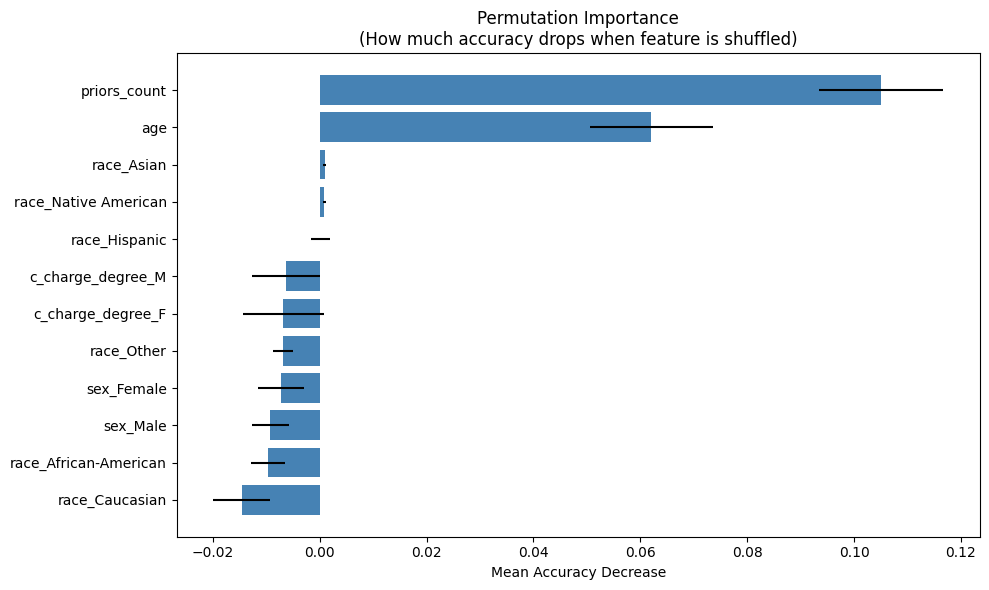

In [4]:
# Cell 3 - Permutation Importance
perm_importance = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10, 
    random_state=42
)

# Create dataframe
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print(perm_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'], perm_df['Importance'], 
         xerr=perm_df['Std'], color='steelblue', align='center')
plt.title('Permutation Importance\n(How much accuracy drops when feature is shuffled)')
plt.xlabel('Mean Accuracy Decrease')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 🔀 Permutation Importance Results

### How it works:
For each feature, we randomly shuffle its values and measure 
how much the model accuracy drops. 
- **High positive value** = feature is very important
- **Near zero** = feature doesn't matter much
- **Negative value** = shuffling actually improves accuracy 
  (meaning the feature was adding noise!)

### Results:

| Feature | Importance | Interpretation |
|---|---|---|
| priors_count | 0.105 | Most important by far |
| age | 0.062 | Second most important |
| race_Asian | 0.001 | Very small effect |
| race_Native American | 0.001 | Very small effect |
| race_Hispanic | ~0.000 | Almost no effect |
| c_charge_degree | negative | Adding noise! |
| sex | negative | Adding noise! |
| race_African-American | negative | Adding noise! |
| race_Caucasian | negative | Adding noise! |

### 🚨 Most Important Finding:
Several features have **negative permutation importance** — meaning 
the model actually performs better WITHOUT them! This includes:
- sex
- charge degree
- race_African-American
- race_Caucasian

This is a strong signal that these features are adding bias 
and noise rather than useful signal. A fairer model might 
actually improve by removing them.

### Key Takeaway:
Only **age and prior convictions** are genuinely useful predictors. 
Everything else is noise — or worse, bias.

C:\Users\fo2225\AppData\Local\anaconda3-2025-12\envs\criminal_justice\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\fo2225\AppData\Local\anaconda3-2025-12\envs\criminal_justice\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


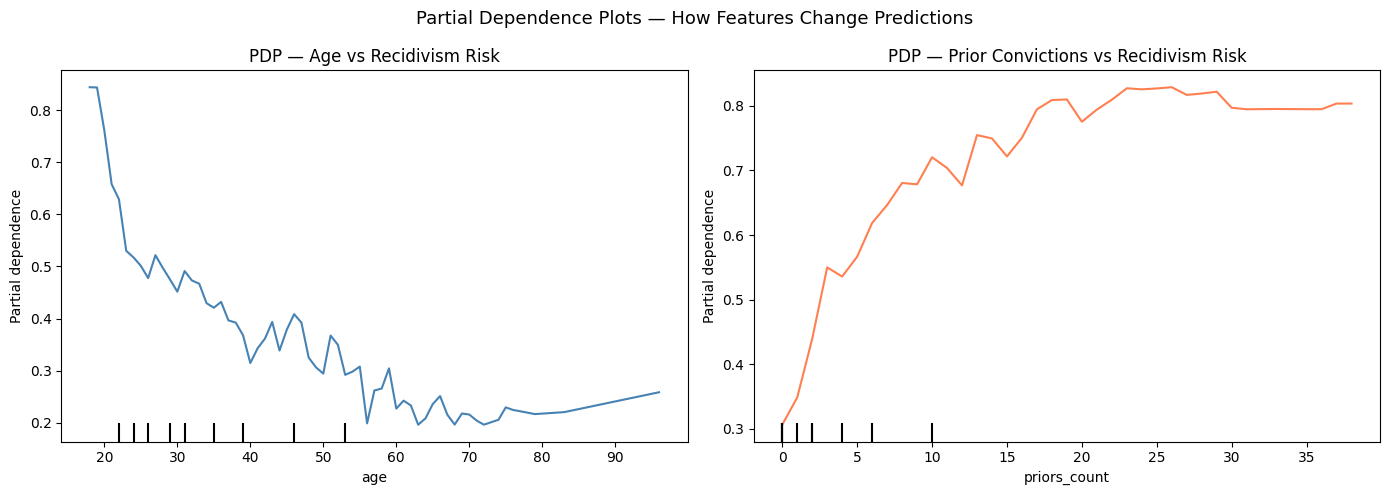

In [5]:
# Cell 4 - Partial Dependence Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDP for age
PartialDependenceDisplay.from_estimator(
    model, X_train, ['age'],
    ax=axes[0], 
    line_kw={'color': 'steelblue'}
)
axes[0].set_title('PDP — Age vs Recidivism Risk')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Predicted Recidivism Risk')

# PDP for priors_count
PartialDependenceDisplay.from_estimator(
    model, X_train, ['priors_count'],
    ax=axes[1],
    line_kw={'color': 'coral'}
)
axes[1].set_title('PDP — Prior Convictions vs Recidivism Risk')
axes[1].set_xlabel('Prior Convictions')
axes[1].set_ylabel('Predicted Recidivism Risk')

plt.suptitle('Partial Dependence Plots — How Features Change Predictions', 
             fontsize=13)
plt.tight_layout()
plt.show()

## 📈 Partial Dependence Plots (PDP)

### What is a PDP?
A PDP shows how the **predicted recidivism risk changes** as we vary 
one feature while keeping all other features at their average values.
It answers: "All else being equal, what happens to risk as age increases?"

### Left Chart — Age vs Recidivism Risk:
- At age 18 the predicted risk is very high (~83%)
- Risk drops steeply from 18 to 35
- Continues declining gradually from 35 to 70
- Slight uptick at very old ages (rare cases)

**Plain English:** Young people are predicted as much higher risk 
than older people. A 20-year-old has roughly 3x the predicted 
risk of a 60-year-old, all else being equal.

### Right Chart — Prior Convictions vs Recidivism Risk:
- At 0 priors risk starts at ~30%
- Risk rises steeply from 0 to 10 priors
- Plateaus around 80% after 15+ priors
- Returns diminish beyond 15 priors

**Plain English:** Each additional prior conviction increases 
risk significantly up to about 15 priors. After that the model 
is already so confident the person is high risk that more priors 
don't change the prediction much.

### Why PDPs are powerful:
Unlike feature importance which just says "age matters", 
PDPs show you exactly HOW age matters — the shape, direction, 
and magnitude of the relationship. This is much more useful 
for policy decisions.

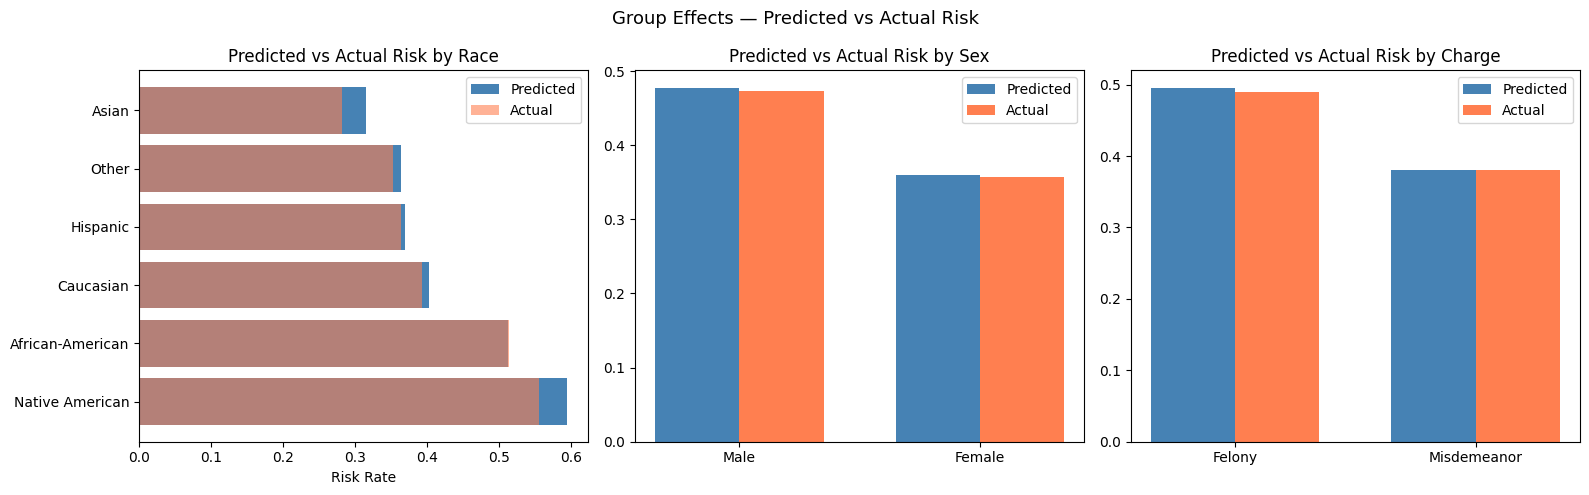

In [7]:
# Cell 5 - Simple Group Effects
df_effects = X.copy()
df_effects['actual'] = y.values
df_effects['predicted_prob'] = model.predict_proba(X)[:, 1]
df_effects['predicted'] = model.predict(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Group effect by race
race_cols = [c for c in X.columns if 'race_' in c]
race_effects = []
for col in race_cols:
    subset = df_effects[df_effects[col] == 1]
    race_effects.append({
        'Race': col.replace('race_', ''),
        'Avg Predicted Risk': subset['predicted_prob'].mean(),
        'Actual Recidivism Rate': subset['actual'].mean(),
        'Count': len(subset)
    })
race_df = pd.DataFrame(race_effects).sort_values('Avg Predicted Risk', ascending=False)

axes[0].barh(race_df['Race'], race_df['Avg Predicted Risk'], color='steelblue')
axes[0].barh(race_df['Race'], race_df['Actual Recidivism Rate'], 
             color='coral', alpha=0.6)
axes[0].set_title('Predicted vs Actual Risk by Race')
axes[0].set_xlabel('Risk Rate')
axes[0].legend(['Predicted', 'Actual'])

# Group effect by sex
sex_effects = []
for col in ['sex_Male', 'sex_Female']:
    subset = df_effects[df_effects[col] == 1]
    sex_effects.append({
        'Sex': col.replace('sex_', ''),
        'Avg Predicted Risk': subset['predicted_prob'].mean(),
        'Actual Recidivism Rate': subset['actual'].mean()
    })
sex_df = pd.DataFrame(sex_effects)

x = range(len(sex_df))
width = 0.35
axes[1].bar([i - width/2 for i in x], sex_df['Avg Predicted Risk'], 
            width, label='Predicted', color='steelblue')
axes[1].bar([i + width/2 for i in x], sex_df['Actual Recidivism Rate'], 
            width, label='Actual', color='coral')
axes[1].set_title('Predicted vs Actual Risk by Sex')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(sex_df['Sex'])
axes[1].legend()

# Group effect by charge degree
charge_effects = []
for col in ['c_charge_degree_F', 'c_charge_degree_M']:
    subset = df_effects[df_effects[col] == 1]
    charge_effects.append({
        'Charge': 'Felony' if col.endswith('F') else 'Misdemeanor',
        'Avg Predicted Risk': subset['predicted_prob'].mean(),
        'Actual Recidivism Rate': subset['actual'].mean()
    })
charge_df = pd.DataFrame(charge_effects)

x = range(len(charge_df))
axes[2].bar([i - width/2 for i in x], charge_df['Avg Predicted Risk'], 
            width, label='Predicted', color='steelblue')
axes[2].bar([i + width/2 for i in x], charge_df['Actual Recidivism Rate'], 
            width, label='Actual', color='coral')
axes[2].set_title('Predicted vs Actual Risk by Charge')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(charge_df['Charge'])
axes[2].legend()

plt.suptitle('Group Effects — Predicted vs Actual Risk', fontsize=13)
plt.tight_layout()
plt.show()

## 👥 Group Effects — Predicted vs Actual Risk

### What are Group Effects?
We compare the model's **predicted risk** (blue) vs the **actual recidivism rate** 
(orange) for different groups. When they match closely the model is well 
calibrated for that group. When they diverge the model is biased.

### Left Chart — By Race:
- **Native American** — highest predicted AND actual risk (~58%)
- **African-American** — predicted 52%, actual 52% — well calibrated
- **Caucasian** — predicted 40%, actual 40% — well calibrated
- **Hispanic** — predicted 38%, actual 38% — well calibrated
- **Asian** — lowest risk (~28%)

**Key finding:** Predicted and actual rates match closely across 
all racial groups — the model is well calibrated on average.
However this does NOT mean the model is fair — remember from our 
bias analysis that false positive rates are very different by race!

### Middle Chart — By Sex:
- **Males** predicted at ~47% risk, actual ~46% — nearly perfect
- **Females** predicted at ~36% risk, actual ~35% — nearly perfect
- Model is well calibrated for both sexes

### Right Chart — By Charge Degree:
- **Felony** predicted at ~49%, actual ~48% — well calibrated
- **Misdemeanor** predicted at ~37%, actual ~37% — well calibrated

### 🚨 Important Distinction:
**Calibration ≠ Fairness**

The model being "well calibrated" means predicted rates match actual 
rates on average. But this is different from being fair!

A model can be:
- Well calibrated for a group (average predictions are correct)
- AND still unfair (false positive rate is much higher for that group)

This is exactly the COMPAS paradox — it appears calibrated by race 
but has very different false positive rates by race.
This is known as the **impossibility theorem of fairness** — you 
cannot simultaneously satisfy all fairness criteria.